In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os

In [2]:
subject_ID = 'S2'
WESAD_path = f'data/WESAD/{subject_ID}/{subject_ID}.pkl'

In [3]:
def load_WESAD_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    
    print(f"Loading data from: {path}")
    with open(path, 'rb') as file:
        data = pickle.load(file, encoding='latin1')

    wrist_data = data['signal']['wrist']

    bvp = wrist_data['BVP']
    acc = wrist_data['ACC']
    temp = wrist_data['TEMP']
    eda = wrist_data['EDA']
    labels = data['label']

    print("Data Loaded Successfully!")
    print(f"BVP shape: {bvp.shape} (64Hz)")
    print(f"ACC shape: {acc.shape} (32Hz)")
    print(f"TEMP shape: {temp.shape} (4Hz)")
    print(f"EDA shape: {eda.shape} (4Hz)")
    print(f"Labels shape: {labels.shape} (7000 samples)")

    return bvp, acc, temp, eda, labels

Loading data from: data/WESAD/S2/S2.pkl
Data Loaded Successfully!
BVP shape: (389056, 1) (64Hz)
ACC shape: (194528, 3) (32Hz)
TEMP shape: (24316, 1) (4Hz)
EDA shape: (24316, 1) (4Hz)
Labels shape: (4255300,) (7000 samples)


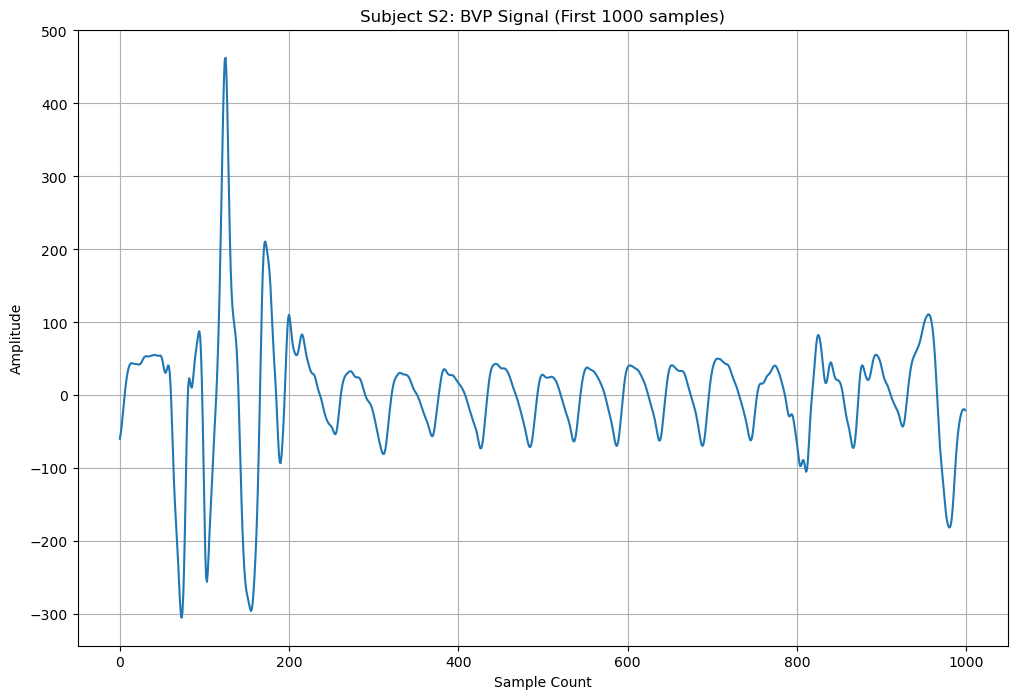

In [4]:
if __name__ == "__main__":
    bvp, acc, temp, eda, labels = load_WESAD_data(WESAD_path)

    plt.figure(figsize=(12, 8))
    plt.plot(bvp[:1000], label='BVP (64Hz)')
    plt.title(f"Subject {subject_ID}: BVP Signal (First 1000 samples)")
    plt.xlabel("Sample Count")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()